# BioListen VN — ESC-50 Dataset Exploratory Data Analysis (EDA)

**Project:** BioListen VN — Hệ thống giám sát âm thanh sinh thái & Phát hiện phá rừng thời gian thực
**Role:** Huỳnh Quốc Việt (AI Lead)
**Dataset:** ESC-50 (Environmental Sound Classification) — Phục vụ nhánh nhận diện các mối đe dọa con người (`human_head`) và làm dữ liệu Pre-training / Baseline.

**Cải tiến tối ưu bộ nhớ:** Notebook này áp dụng chiến lược **On-Demand/Lazy Extraction** - chỉ đọc metadata CSV từ file zip và giải nén tạm thời các mẫu cần thiết. Điều này giúp chạy mượt mà trên Google Colab mà không lo đầy ổ cứng (sử dụng gần 0 MB dung lượng Colab disk).

## 1. Kết nối Google Drive và cấu hình đường dẫn

Thay vì giải nén toàn bộ file zip hàng GB vào Colab, chúng ta chỉ cần kết nối Drive và thao tác trực tiếp với file zip qua thư viện `zipfile` của Python.

In [11]:
# Mount Google Drive vào Colab
from google.colab import drive
drive.mount('/content/drive')

import os
import zipfile
import shutil

# Đường dẫn lưu file zip trên Drive của bạn
zip_path = '/content/drive/MyDrive/Datasets/BioListenVN/raw_zips/ESC-50-master.zip'
temp_extract_dir = '/content/esc50_temp_samples'

if os.path.exists(zip_path):
    print(f"Tìm thấy file zip tại: {zip_path}")
    # Tạo thư mục chứa các file tạm để visual
    os.makedirs(temp_extract_dir, exist_ok=True)
else:
    print(f"Cảnh báo: Không tìm thấy file tại {zip_path}. Vui lòng kiểm tra lại cấu trúc thư mục trên Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tìm thấy file zip tại: /content/drive/MyDrive/Datasets/BioListenVN/raw_zips/ESC-50-master.zip


## 2. Import các thư viện cần thiết

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd
import torchaudio
import torchaudio.transforms as T
import torch
import glob
import random

sns.set_theme(style="whitegrid")
print("PyTorch version:", torch.__version__)
print("Torchaudio version:", torchaudio.__version__)
print("Librosa version:", librosa.__version__)

PyTorch version: 2.11.0+cpu
Torchaudio version: 2.11.0+cpu
Librosa version: 0.11.0


## 3. Khám phá cấu trúc metadata của ESC-50 từ file Zip

Chúng ta đọc trực tiếp file `esc50.csv` từ bên trong file zip mà không cần giải nén bất kỳ file âm thanh nào.

In [13]:
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as z:
        # Tìm file esc50.csv trong file zip
        csv_files = [f for f in z.namelist() if f.endswith('esc50.csv')]
        print("Các file CSV tìm thấy trong Zip:", csv_files)

        if len(csv_files) > 0:
            with z.open(csv_files[0]) as f:
                df = pd.read_csv(f)
            print(f"Đã đọc file metadata trực tiếp từ zip: {csv_files[0]}")
            print(f"Kích thước DataFrame: {df.shape}")

            # Lưu lại danh sách đường dẫn tất cả file audio trong zip để tìm kiếm nhanh
            print("Đang lập chỉ mục danh sách file audio trong zip...")
            all_files = z.namelist()
            audio_in_zip = [p for p in all_files if p.endswith('.wav')]
            file_to_zip_path = {os.path.basename(p): p for p in audio_in_zip}

            print("\n5 dòng đầu của metadata:")
            display(df.head())
            print("\nThông tin các cột:")
            df.info()
        else:
            print("Không tìm thấy file metadata esc50.csv trong file zip!")
else:
    print("Vui lòng cấu hình đúng đường dẫn zip_path.")

Các file CSV tìm thấy trong Zip: ['ESC-50-master/meta/esc50.csv']
Đã đọc file metadata trực tiếp từ zip: ESC-50-master/meta/esc50.csv
Kích thước DataFrame: (2000, 7)
Đang lập chỉ mục danh sách file audio trong zip...

5 dòng đầu của metadata:


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A



Thông tin các cột:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  2000 non-null   object
 1   fold      2000 non-null   int64 
 2   target    2000 non-null   int64 
 3   category  2000 non-null   object
 4   esc10     2000 non-null   bool  
 5   src_file  2000 non-null   int64 
 6   take      2000 non-null   object
dtypes: bool(1), int64(3), object(3)
memory usage: 95.8+ KB


## 4. Phân tích phân phối các lớp âm thanh (Class Distribution)

Bộ dữ liệu ESC-50 có đặc điểm là cân bằng hoàn hảo (perfectly balanced) với 50 lớp, mỗi lớp có đúng 40 mẫu. Chúng ta lọc ra các lớp liên quan trực tiếp đến dự án BioListen VN.

Tổng số lớp âm thanh: 50

Danh sách 50 lớp trong ESC-50:
airplane, breathing, brushing_teeth, can_opening, car_horn
cat, chainsaw, chirping_birds, church_bells, clapping
clock_alarm, clock_tick, coughing, cow, crackling_fire
crickets, crow, crying_baby, dog, door_wood_creaks
door_wood_knock, drinking_sipping, engine, fireworks, footsteps
frog, glass_breaking, hand_saw, helicopter, hen
insects, keyboard_typing, laughing, mouse_click, pig
pouring_water, rain, rooster, sea_waves, sheep
siren, sneezing, snoring, thunderstorm, toilet_flush
train, vacuum_cleaner, washing_machine, water_drops, wind

Số lượng mẫu của lớp CHAINSAW: 40

Số lượng mẫu của lớp AIRPLANE: 40

Số lượng mẫu của lớp BREATHING: 40

Số lượng mẫu của lớp ENGINEHELICOPTER: 0

Số lượng mẫu của lớp RAIN: 40

Số lượng mẫu của lớp LAUGHING: 40

Số lượng mẫu của lớp WIND: 40

Số lượng mẫu của lớp SNEEZING: 40

Số lượng mẫu của lớp SNORING: 40

Số lượng mẫu của lớp THUNDERSTORM: 40

Số lượng mẫu của lớp CRICKETS: 40

Số lượng mẫu

/tmp/ipykernel_940/1619839407.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='fold', palette='Blues_d')


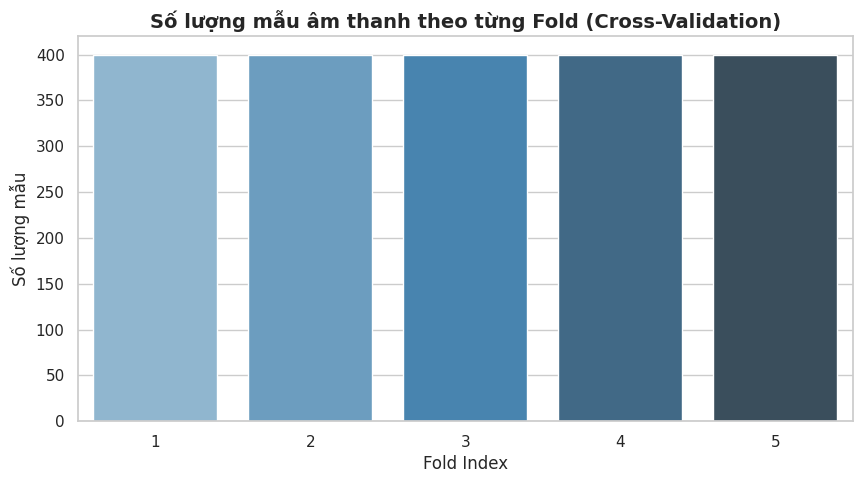

In [18]:
if 'df' in locals():
    num_classes = df['category'].nunique()
    print(f"Tổng số lớp âm thanh: {num_classes}")

    all_classes = sorted(df['category'].unique())
    print("\nDanh sách 50 lớp trong ESC-50:")
    for i in range(0, len(all_classes), 5):
        print(", ".join(all_classes[i:i+5]))

    for cls in ['chainsaw', 'airplane', 'breathing', 'engine'  'helicopter', 'rain', 'laughing', 'wind', 'sneezing', 'snoring', 'thunderstorm', 'crickets', 'car_horn', 'footsteps', 'fireworks']:
      print(f"\nSố lượng mẫu của lớp {cls.upper()}: {len(df[df['category'] == cls])}")
    # Các lớp quan trọng cho dự án
    biolisten_classes = ['chainsaw', 'airplane', 'breathing', 'engine'  'helicopter', 'rain', 'laughing', 'wind', 'sneezing', 'snoring', 'thunderstorm', 'crickets', 'chirping_birds', 'footsteps', 'fireworks']
    print(f"\nCác lớp cực kỳ hữu ích cho BioListen VN: {biolisten_classes}")
    print(f"Tổng số lớp quan trọng {len(biolisten_classes) + 1}")
    filtered_df = df[df['category'].isin(biolisten_classes)]
    print(f"Số lượng mẫu của các lớp được chọn: {len(filtered_df)}")

    # Vẽ biểu đồ phân phối mẫu theo fold
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x='fold', palette='Blues_d')
    plt.title("Số lượng mẫu âm thanh theo từng Fold (Cross-Validation)", fontsize=14, fontweight='bold')
    plt.xlabel("Fold Index")
    plt.ylabel("Số lượng mẫu")
    plt.show()

## 5. Thống kê đặc tính Vật lý bằng On-Demand Extraction

Chúng ta chỉ giải nén khoảng 20 file ngẫu nhiên, đọc thông số vật lý của chúng, sau đó xóa ngay để giải phóng bộ nhớ.

In [15]:
import tqdm

if 'df' in locals() and 'file_to_zip_path' in locals():
    sample_df = df.sample(20, random_state=42)
    durations = []
    sample_rates = []
    channels = []
    extracted_paths = []

    print(f"Đang giải nén tạm thời {len(sample_df)} file audio để phân tích...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        for idx, row in tqdm.tqdm(sample_df.iterrows(), total=len(sample_df)):
            fname = row['filename']
            if fname in file_to_zip_path:
                zip_member = file_to_zip_path[fname]
                target_path = os.path.join(temp_extract_dir, fname)

                with z.open(zip_member) as source, open(target_path, 'wb') as target:
                    shutil.copyfileobj(source, target)

                waveform, sample_rate = torchaudio.load(target_path)

                sample_rates.append(sample_rate)
                durations.append(waveform.shape[1] / sample_rate)
                channels.append(waveform.shape[0])
                extracted_paths.append(target_path)

    print("\n--- THÔNG SỐ VẬT LÝ PHÁT HIỆN (20 MẪU) ---")
    print(f"Sample Rates: {set(sample_rates)} Hz")
    print(f"Số kênh âm thanh (Channels): {set(channels)} (1 = Mono)")
    print(f"Thời lượng (Duration): {set([round(d, 2) for d in durations])} giây")

    # Dọn dẹp
    for p in extracted_paths:
        if os.path.exists(p):
            os.remove(p)
    print("Đã dọn dẹp các file tạm khỏi ổ cứng Colab!")

Đang giải nén tạm thời 20 file audio để phân tích...


100%|██████████| 20/20 [00:00<00:00, 36.74it/s]


--- THÔNG SỐ VẬT LÝ PHÁT HIỆN (20 MẪU) ---
Sample Rates: {44100} Hz
Số kênh âm thanh (Channels): {1} (1 = Mono)
Thời lượng (Duration): {5.0} giây
Đã dọn dẹp các file tạm khỏi ổ cứng Colab!


## 6. Trực quan hóa Waveform & Log-Mel Spectrogram

Vẽ dạng sóng và biểu đồ tần số bằng hàm tự động giải nén và dọn dẹp.


Đang vẽ đồ thị mẫu âm thanh lớp: CHAINSAW...


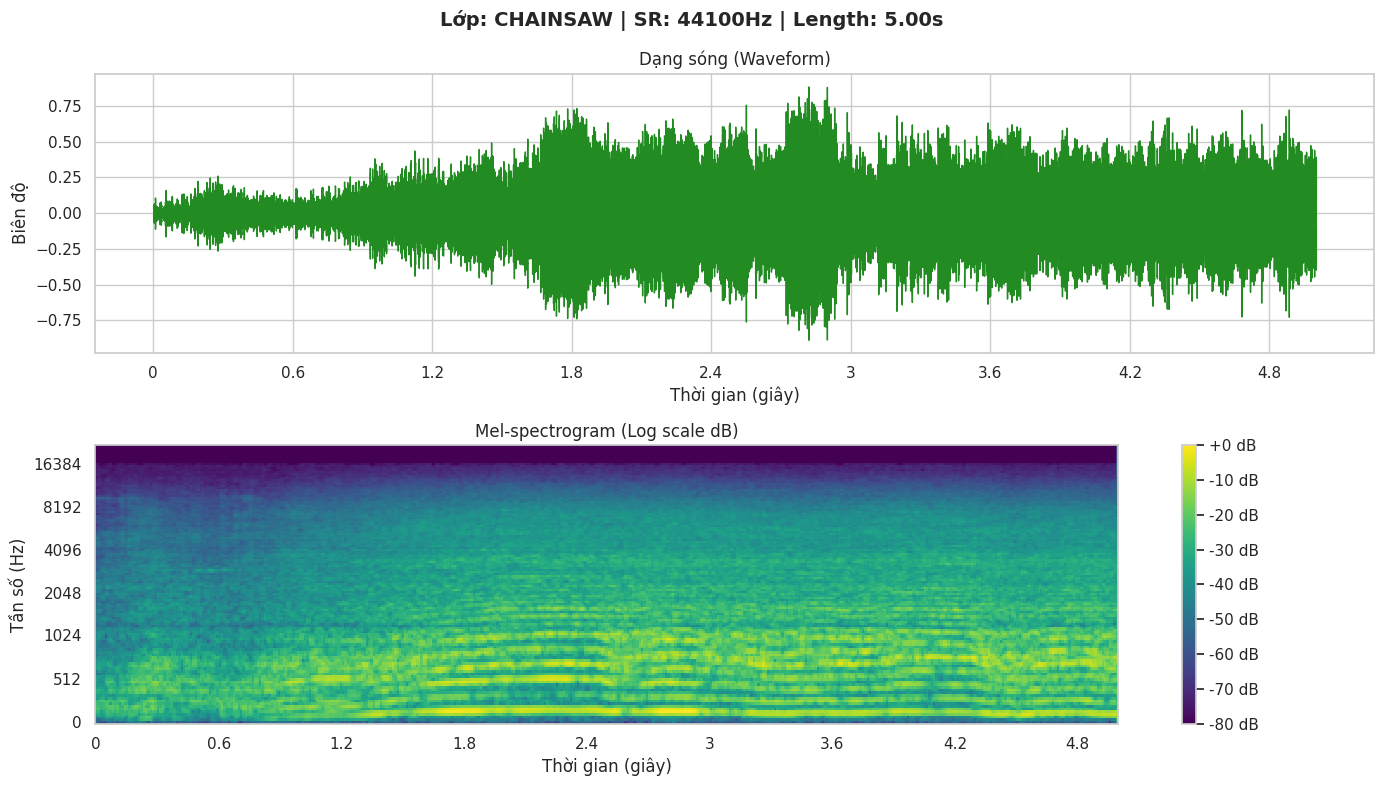


Đang vẽ đồ thị mẫu âm thanh lớp: RAIN...


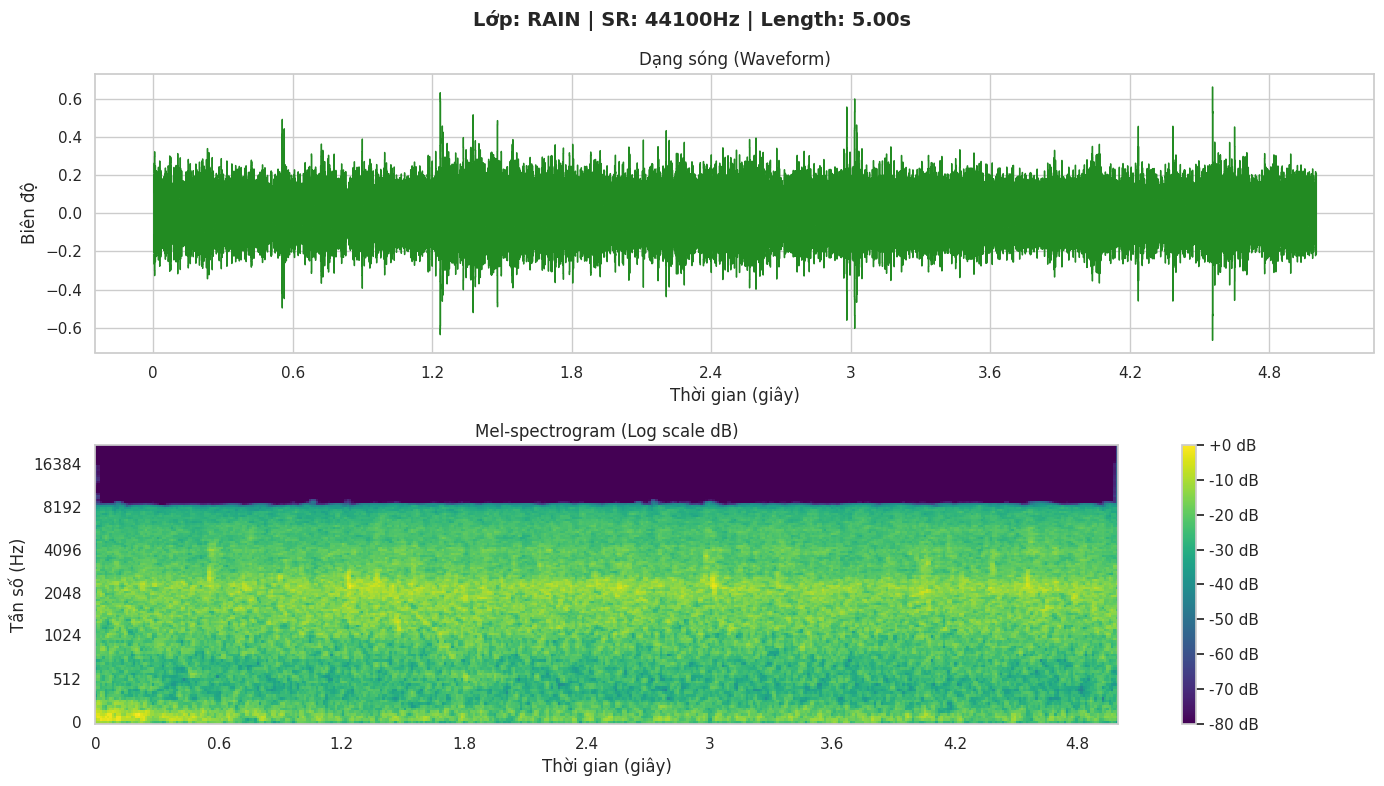

In [16]:
def plot_audio_sample(file_path, label):
    y, sr = librosa.load(file_path, sr=None)
    duration = len(y) / sr

    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)

    fig, ax = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle(f"Lớp: {label.upper()} | SR: {sr}Hz | Length: {duration:.2f}s", fontsize=14, fontweight='bold')

    # 1. Waveform
    librosa.display.waveshow(y, sr=sr, ax=ax[0], color='forestgreen')
    ax[0].set_title("Dạng sóng (Waveform)")
    ax[0].set_xlabel("Thời gian (giây)")
    ax[0].set_ylabel("Biên độ")

    # 2. Spectrogram
    img = librosa.display.specshow(S_db, sr=sr, hop_length=512, x_axis='time', y_axis='mel', ax=ax[1], cmap='viridis')
    ax[1].set_title("Mel-spectrogram (Log scale dB)")
    ax[1].set_xlabel("Thời gian (giây)")
    ax[1].set_ylabel("Tần số (Hz)")
    fig.colorbar(img, ax=ax[1], format="%+2.0f dB")

    plt.tight_layout()
    plt.show()
    display(ipd.Audio(y, rate=sr))

def extract_and_plot(label):
    class_samples = df[df['category'] == label]
    if not class_samples.empty:
        fname = class_samples.iloc[0]['filename']
        if fname in file_to_zip_path:
            zip_member = file_to_zip_path[fname]
            temp_file = os.path.join(temp_extract_dir, fname)

            with zipfile.ZipFile(zip_path, 'r') as z:
                with z.open(zip_member) as source, open(temp_file, 'wb') as target:
                    shutil.copyfileobj(source, target)

            plot_audio_sample(temp_file, label)

            if os.path.exists(temp_file):
                os.remove(temp_file)

if 'df' in locals():
    for cls in ['chainsaw', 'rain']:
        print(f"\nĐang vẽ đồ thị mẫu âm thanh lớp: {cls.upper()}...")
        extract_and_plot(cls)

## 7. Thiết kế Preprocessing Pipeline cho PyTorch Model

Chạy thử nghiệm preprocessor trên một file tạm để xác nhận pipeline ảnh (3, 224, 224) hoạt động chính xác.


--- TEST PIPELINE TIỀN XỬ LÝ (Lớp: WIND) ---
Dạng sóng sau xử lý: torch.Size([1, 110250])
Spectrogram gốc (dB) shape: torch.Size([1, 128, 216])
Tensor RGB shape: torch.Size([3, 224, 224])


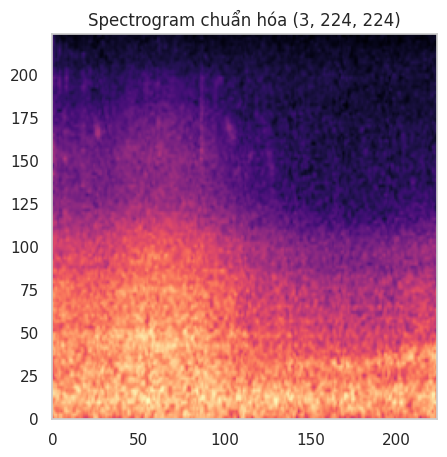

In [17]:
class ESC50AudioPreprocessor:
    def __init__(self, sample_rate=22050, duration=5, n_fft=2048, hop_length=512, n_mels=128):
        self.target_sr = sample_rate
        self.duration = duration
        self.target_samples = sample_rate * duration
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_mels = n_mels

        self.mel_spectrogram = T.MelSpectrogram(
            sample_rate=self.target_sr,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels
        )
        self.amplitude_to_db = T.AmplitudeToDB()

    def preprocess(self, file_path):
        waveform, sr = torchaudio.load(file_path)
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        if sr != self.target_sr:
            resampler = T.Resample(orig_freq=sr, new_freq=self.target_sr)
            waveform = resampler(waveform)

        num_samples = waveform.shape[1]
        if num_samples > self.target_samples:
            waveform = waveform[:, :self.target_samples]
        elif num_samples < self.target_samples:
            pad_len = self.target_samples - num_samples
            waveform = torch.nn.functional.pad(waveform, (0, pad_len))

        mel_spec = self.mel_spectrogram(waveform)
        mel_spec_db = self.amplitude_to_db(mel_spec)

        min_val = mel_spec_db.min()
        max_val = mel_spec_db.max()
        if max_val - min_val > 1e-9:
            mel_spec_norm = (mel_spec_db - min_val) / (max_val - min_val)
        else:
            mel_spec_norm = torch.zeros_like(mel_spec_db)

        mel_spec_unsqueezed = mel_spec_norm.unsqueeze(0)
        mel_spec_resized = torch.nn.functional.interpolate(
            mel_spec_unsqueezed,
            size=(224, 224),
            mode='bilinear',
            align_corners=False
        ).squeeze(0)

        mel_rgb = mel_spec_resized.repeat(3, 1, 1)

        return waveform, mel_spec_db, mel_rgb

if 'df' in locals() and len(df) > 0:
    test_file = df.sample(1).iloc[0]
    fname = test_file['filename']
    if fname in file_to_zip_path:
        zip_member = file_to_zip_path[fname]
        temp_file = os.path.join(temp_extract_dir, fname)

        # Giải nén tạm thời
        with zipfile.ZipFile(zip_path, 'r') as z:
            with z.open(zip_member) as source, open(temp_file, 'wb') as target:
                shutil.copyfileobj(source, target)

        preprocessor = ESC50AudioPreprocessor()
        waveform, spec_db, mel_rgb = preprocessor.preprocess(temp_file)
        print(f"\n--- TEST PIPELINE TIỀN XỬ LÝ (Lớp: {test_file['category'].upper()}) ---")
        print("Dạng sóng sau xử lý:", waveform.shape)
        print("Spectrogram gốc (dB) shape:", spec_db.shape)
        print("Tensor RGB shape:", mel_rgb.shape)

        plt.figure(figsize=(5, 5))
        plt.imshow(mel_rgb[0].numpy(), cmap='magma', origin='lower')
        plt.title("Spectrogram chuẩn hóa (3, 224, 224)")
        plt.grid(False)
        plt.show()

        if os.path.exists(temp_file):
            os.remove(temp_file)

## 8. Kết luận & Định hướng tiếp theo

* ESC-50 có thể được thao tác và phân tích hoàn hảo trên Colab bằng phương pháp On-Demand zip loading.
* Tận dụng các lớp trùng khớp để thực hiện Transfer/Multi-task learning cho BioListen VN.